# Evaluation of the method to improve GWAS power

## Introduction

In this file, we want to start collecting pieces to evaluate the method.

For now, we only evaluated individual GWAS studies, showing the potential of the method without the sample size to make statements about the general applicability. Therefore, we want to apply the method to a large collection of GWASs run in the PanUKBB study.

The metrics to measure the success of the method will be the significant associations recovered from the original study and the newly found associations. If there is a clear trend on a large scale of finding more associated loci without losing established associations, the method can be considered an improvement to the state of the art.

A way of evaluating the comparative power of the approach would be to recover findings of a GWAS study with a subset of the data. Unfortunately, we don't have individual-level data for the PanUKBB GWASs and therefore cannot do the evaluation on this data.

The GWAS results can be accessed through a google spreadsheet ([Phenotype Manuscript](https://docs.google.com/spreadsheets/d/1AeeADtT0U1AukliiNyiVzVRdLYPkTbruQSk38DeutU8/edit?gid=1450719288#gid=1450719288)). The file "phenotype_manifest.csv" contains the downloaded table (*Download* -> *Comma-separated values (.csv, current sheet)* under the *File* menu in the top toolbar of the google spreadsheet).

For an initial evaluation we chose to use a maximally independent subset of phenotypes, provided by the authors of the study (*in_max_independent_set* attribute).

## Data handling

### Importing the table

In [19]:
import pandas as pd

In [20]:
# description: for SAD track selection
#   (description_more and coding_description contain further (differentiating)
#   information, but should not be relevant for SAD track selection)
# in_max_independent_set: to identify the initial evaluation set
# filename: for automating data handling after download
# filename_tabix: The tabix files can be used to more efficiently access subsets
#   of the data and should be used for the initial filtering of SNPs we have
#   SAD data for
# wget: for automatic download
# wget_tabix: for automatic download of the tabix file
# size_in_bytes: to gauge storage demand
phenotype_manifest = pd.read_csv("phenotype_manifest.csv", usecols=[
    # as input to GPT:
    'description',
    'description_more',
    'trait_type',
    'category',
    # for filtering:
    'in_max_independent_set',
    # for download and automatic data handling:
    'filename',
    'filename_tabix',
    'wget',
    'wget_tabix',
    # for file size estimates:
    'size_in_bytes',
    # for heritability estimates:
    'sldsc_25bin_h2_observed_EUR',
    # for data cleaning:
    'phenocode',
    # for pathological phenotypes:
    'coding',
    'coding_description',
    'n_cases_EUR'
    ])

### Pathological phenotypes:

#### Investigating pathological phenotypes (part 1: actually the wrong phenotypes)

In [3]:
pathological_phenotypes = phenotype_manifest[phenotype_manifest['phenocode']=='41200']

In [4]:
pathological_phenotypes.head()

,trait_type,phenocode,coding,description,description_more,coding_description,category,n_cases_EUR,sldsc_25bin_h2_observed_EUR,in_max_independent_set,filename,filename_tabix,wget,wget_tabix,size_in_bytes
1873,categorical,41200,A021,Operative procedures - main OPCS4,This field is a summary of the main operation ...,A02.1 Excision of lesion of tissue of frontal ...,Health-related outcomes > Hospital inpatient >...,176.0,0.0039,False,categorical-41200-both_sexes-A021.tsv.bgz,categorical-41200-both_sexes-A021.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,517192238
1874,categorical,41200,A022,Operative procedures - main OPCS4,This field is a summary of the main operation ...,A02.2 Excision of lesion of tissue of temporal...,Health-related outcomes > Hospital inpatient >...,143.0,0.0012,False,categorical-41200-both_sexes-A022.tsv.bgz,categorical-41200-both_sexes-A022.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,515208962
1875,categorical,41200,A107,Operative procedures - main OPCS4,This field is a summary of the main operation ...,A10.7 Stereotactic radiosurgery on tissue of b...,Health-related outcomes > Hospital inpatient >...,131.0,0.0035,False,categorical-41200-both_sexes-A107.tsv.bgz,categorical-41200-both_sexes-A107.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,513865501
1876,categorical,41200,A124,Operative procedures - main OPCS4,This field is a summary of the main operation ...,A12.4 Creation of ventriculoperitoneal shunt,Health-related outcomes > Hospital inpatient >...,128.0,0.0035,False,categorical-41200-both_sexes-A124.tsv.bgz,categorical-41200-both_sexes-A124.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,514586901
1877,categorical,41200,A295,Operative procedures - main OPCS4,This field is a summary of the main operation ...,A29.5 Excision of lesion of acoustic nerve (viii),Health-related outcomes > Hospital inpatient >...,124.0,0.0043,False,categorical-41200-both_sexes-A295.tsv.bgz,categorical-41200-both_sexes-A295.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,513388743


In [5]:
pathological_phenotypes = pathological_phenotypes[pathological_phenotypes['coding'].str[:3].str.match(r'^[C-R][0-9]{2}$')]

In [6]:
pathological_phenotypes.head()

,trait_type,phenocode,coding,description,description_more,coding_description,category,n_cases_EUR,sldsc_25bin_h2_observed_EUR,in_max_independent_set,filename,filename_tabix,wget,wget_tabix,size_in_bytes
1964,categorical,41200,C101,Operative procedures - main OPCS4,This field is a summary of the main operation ...,C10.1 Excision of lesion of eyebrow,Health-related outcomes > Hospital inpatient >...,511.0,-0.00030,False,categorical-41200-both_sexes-C101.tsv.bgz,categorical-41200-both_sexes-C101.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,532271374
1965,categorical,41200,C111,Operative procedures - main OPCS4,This field is a summary of the main operation ...,C11.1 Excision of lesion of canthus,Health-related outcomes > Hospital inpatient >...,1077.0,-0.00004,False,categorical-41200-both_sexes-C111.tsv.bgz,categorical-41200-both_sexes-C111.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,539118209
1966,categorical,41200,C118,Operative procedures - main OPCS4,This field is a summary of the main operation ...,C11.8 Other specified operations on canthus,Health-related outcomes > Hospital inpatient >...,106.0,-0.00100,False,categorical-41200-both_sexes-C118.tsv.bgz,categorical-41200-both_sexes-C118.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,511631558
1967,categorical,41200,C121,Operative procedures - main OPCS4,This field is a summary of the main operation ...,C12.1 Excision of lesion of eyelid NEC,Health-related outcomes > Hospital inpatient >...,4594.0,0.00560,False,categorical-41200-both_sexes-C121.tsv.bgz,categorical-41200-both_sexes-C121.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,1114266796
1968,categorical,41200,C122,Operative procedures - main OPCS4,This field is a summary of the main operation ...,C12.2 Cauterisation of lesion of eyelid,Health-related outcomes > Hospital inpatient >...,171.0,-0.00130,False,categorical-41200-both_sexes-C122.tsv.bgz,categorical-41200-both_sexes-C122.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,517282620


In [7]:

pathological_phenotypes.tail()

,trait_type,phenocode,coding,description,description_more,coding_description,category,n_cases_EUR,sldsc_25bin_h2_observed_EUR,in_max_independent_set,filename,filename_tabix,wget,wget_tabix,size_in_bytes
2563,categorical,41200,R182,Operative procedures - main OPCS4,This field is a summary of the main operation ...,R18.2 Lower uterine segment caesarean delivery...,Health-related outcomes > Hospital inpatient >...,2003.0,0.0003,False,categorical-41200-both_sexes-R182.tsv.bgz,categorical-41200-both_sexes-R182.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,1569190644
2564,categorical,41200,R222,Operative procedures - main OPCS4,This field is a summary of the main operation ...,R22.2 Low vacuum delivery,Health-related outcomes > Hospital inpatient >...,459.0,0.0017,False,categorical-41200-both_sexes-R222.tsv.bgz,categorical-41200-both_sexes-R222.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,530592658
2565,categorical,41200,R228,Operative procedures - main OPCS4,This field is a summary of the main operation ...,R22.8 Other specified vacuum delivery,Health-related outcomes > Hospital inpatient >...,105.0,0.0044,False,categorical-41200-both_sexes-R228.tsv.bgz,categorical-41200-both_sexes-R228.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,511329277
2566,categorical,41200,R229,Operative procedures - main OPCS4,This field is a summary of the main operation ...,R22.9 Unspecified vacuum delivery,Health-related outcomes > Hospital inpatient >...,699.0,0.1880,False,categorical-41200-both_sexes-R229.tsv.bgz,categorical-41200-both_sexes-R229.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,535542248
2567,categorical,41200,R249,Operative procedures - main OPCS4,This field is a summary of the main operation ...,R24.9 All normal delivery,Health-related outcomes > Hospital inpatient >...,7108.0,0.0196,False,categorical-41200-both_sexes-R249.tsv.bgz,categorical-41200-both_sexes-R249.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,2107363334


In [8]:
len(pathological_phenotypes)

604

In [9]:
len(pathological_phenotypes[pathological_phenotypes['n_cases_EUR']>100])

596

In [14]:
len(pathological_phenotypes[(pathological_phenotypes['n_cases_EUR']<5000) & (pathological_phenotypes['n_cases_EUR']>100)])

575

In [17]:
pathological_phenotypes[(pathological_phenotypes['n_cases_EUR']<5000) & (pathological_phenotypes['n_cases_EUR']>100)].head(7)

,trait_type,phenocode,coding,description,description_more,coding_description,category,n_cases_EUR,sldsc_25bin_h2_observed_EUR,in_max_independent_set,filename,filename_tabix,wget,wget_tabix,size_in_bytes
1964,categorical,41200,C101,Operative procedures - main OPCS4,This field is a summary of the main operation ...,C10.1 Excision of lesion of eyebrow,Health-related outcomes > Hospital inpatient >...,511.0,-0.00030,False,categorical-41200-both_sexes-C101.tsv.bgz,categorical-41200-both_sexes-C101.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,532271374
1965,categorical,41200,C111,Operative procedures - main OPCS4,This field is a summary of the main operation ...,C11.1 Excision of lesion of canthus,Health-related outcomes > Hospital inpatient >...,1077.0,-0.00004,False,categorical-41200-both_sexes-C111.tsv.bgz,categorical-41200-both_sexes-C111.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,539118209
1966,categorical,41200,C118,Operative procedures - main OPCS4,This field is a summary of the main operation ...,C11.8 Other specified operations on canthus,Health-related outcomes > Hospital inpatient >...,106.0,-0.00100,False,categorical-41200-both_sexes-C118.tsv.bgz,categorical-41200-both_sexes-C118.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,511631558
1967,categorical,41200,C121,Operative procedures - main OPCS4,This field is a summary of the main operation ...,C12.1 Excision of lesion of eyelid NEC,Health-related outcomes > Hospital inpatient >...,4594.0,0.00560,False,categorical-41200-both_sexes-C121.tsv.bgz,categorical-41200-both_sexes-C121.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,1114266796
1968,categorical,41200,C122,Operative procedures - main OPCS4,This field is a summary of the main operation ...,C12.2 Cauterisation of lesion of eyelid,Health-related outcomes > Hospital inpatient >...,171.0,-0.00130,False,categorical-41200-both_sexes-C122.tsv.bgz,categorical-41200-both_sexes-C122.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,517282620
1969,categorical,41200,C124,Operative procedures - main OPCS4,This field is a summary of the main operation ...,C12.4 Curettage of lesion of eyelid,Health-related outcomes > Hospital inpatient >...,1705.0,0.00400,False,categorical-41200-both_sexes-C124.tsv.bgz,categorical-41200-both_sexes-C124.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,1073087202
1971,categorical,41200,C131,Operative procedures - main OPCS4,This field is a summary of the main operation ...,C13.1 Blepharoplasty of both eyelids,Health-related outcomes > Hospital inpatient >...,218.0,0.00690,False,categorical-41200-both_sexes-C131.tsv.bgz,categorical-41200-both_sexes-C131.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,521246496


Oh no, this is not the ICD10 diseases!

#### Investigating pathological phenotypes (part 2: the correct phenotypes)

###### Downloading the ICD10-to-phecode file (only execute this once)

In [4]:
import os

In [24]:
os.system('wget https://raw.githubusercontent.com/atgu/ukbb_pan_ancestry/refs/heads/master/data/UKB_PHENOME_ICD10_PHECODE_MAP_20200109.txt')

--2025-03-31 10:51:48--  https://raw.githubusercontent.com/atgu/ukbb_pan_ancestry/refs/heads/master/data/UKB_PHENOME_ICD10_PHECODE_MAP_20200109.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3716776 (3.5M) [text/plain]
Saving to: ‘UKB_PHENOME_ICD10_PHECODE_MAP_20200109.txt’

     0K .......... .......... .......... .......... ..........  1%  413K 9s
    50K .......... .......... .......... .......... ..........  2%  785K 7s
   100K .......... .......... .......... .......... ..........  4% 1.41M 5s
   150K .......... .......... .......... .......... ..........  5%  942K 5s
   200K .......... .......... .......... .......... ..........  6%  461K 5s
   250K .......... .......... .......... .......... ..........  8%  411K 6s
   300K .......... .......... .

0

###### Filtering the ICD10-to-phecode file

In [21]:
icd_diseases = pd.read_csv('UKB_PHENOME_ICD10_PHECODE_MAP_20200109.txt', sep='\t')

In [22]:
icd_diseases.head()

,ICD10,meaning,node_id,parent_id,selectable,phecode,description,group,groupnum,added,sex,rollup,leaf
0,A00,A00 Cholera,286,23,N,8.0,Intestinal infection,infectious diseases,1,original,Both,1.0,0.0
1,A00.0,"A00.0 Cholera due to Vibrio cholerae 01, biova...",287,286,Y,8.0,Intestinal infection,infectious diseases,1,original,Both,1.0,0.0
2,A00.1,"A00.1 Cholera due to Vibrio cholerae 01, biova...",288,286,Y,8.0,Intestinal infection,infectious diseases,1,original,Both,1.0,0.0
3,A00.9,"A00.9 Cholera, unspecified",289,286,Y,8.0,Intestinal infection,infectious diseases,1,original,Both,1.0,0.0
4,A01,A01 Typhoid and paratyphoid fevers,290,23,N,8.0,Intestinal infection,infectious diseases,1,original,Both,1.0,0.0


There is no codes with three digits before the point:

In [5]:
icd_diseases[icd_diseases['ICD10'].str.match(r'^[A-Z]\d{3}$')].head()

,ICD10,meaning,node_id,parent_id,selectable,phecode,description,group,groupnum,added,sex,rollup,leaf


This inital filtering approach with regexes is flawed, it includes R90 to R99 which they don't include in the paper

In [14]:
icd_diseases_old = icd_diseases[icd_diseases['ICD10'].str[:3].str.match(r'^[C-R][0-9]{2}$')]

In [23]:
icd_diseases = icd_diseases[(icd_diseases['ICD10'] >= 'C01') & (icd_diseases['ICD10'] <= 'R90')]

A quick look at the data:

In [7]:
icd_diseases.sort_values('ICD10')

,ICD10,meaning,node_id,parent_id,selectable,phecode,description,group,groupnum,added,sex,rollup,leaf
2234,C01,C01 Malignant neoplasm of base of tongue,1217,44,Y,145.0,Cancer of mouth,neoplasms,2,rolled up PheWAS code,Both,1.0,0.0
2281,C01,C01 Malignant neoplasm of base of tongue,1217,44,Y,145.2,Cancer of tongue,neoplasms,2,original,Both,1.0,1.0
2235,C02,C02 Malignant neoplasm of other and unspecifie...,1218,44,N,145.0,Cancer of mouth,neoplasms,2,rolled up PheWAS code,Both,1.0,0.0
2282,C02,C02 Malignant neoplasm of other and unspecifie...,1218,44,N,145.2,Cancer of tongue,neoplasms,2,original,Both,1.0,1.0
2283,C02.0,C02.0 Dorsal surface of tongue,1219,1218,Y,145.2,Cancer of tongue,neoplasms,2,original,Both,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1409,R89.5,R89.5 Abnormal microbiological findings,12633,12627,Y,1010.0,Other tests,injuries & poisonings,18,original,Both,1.0,0.0
1410,R89.6,R89.6 Abnormal cytological findings,12634,12627,Y,1010.0,Other tests,injuries & poisonings,18,original,Both,1.0,0.0
1411,R89.7,R89.7 Abnormal histological findings,12635,12627,Y,1010.0,Other tests,injuries & poisonings,18,original,Both,1.0,0.0
1412,R89.8,R89.8 Other abnormal findings,12636,12627,Y,1010.0,Other tests,injuries & poisonings,18,original,Both,1.0,0.0


The filtering seems to be correct.

###### Filter the phenotype manifest based on the ICD10 disease codes

In [24]:
phecodes = icd_diseases['phecode'].unique().tolist()

In [25]:
icd_filter=phenotype_manifest['phenocode'].isin([str(code) for code in phecodes])

In [26]:
len(phenotype_manifest[icd_filter])

763

A look at the data:

In [11]:
phenotype_manifest[icd_filter]

,trait_type,phenocode,coding,description,description_more,coding_description,category,n_cases_EUR,sldsc_25bin_h2_observed_EUR,in_max_independent_set,filename,filename_tabix,wget,wget_tabix,size_in_bytes
5466,phecode,41.1,NaN,Staphylococcus infections,NaN,NaN,infectious diseases,3852.0,0.0008,False,phecode-041.1-both_sexes.tsv.bgz,phecode-041.1-both_sexes.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,1565104355
5467,phecode,41.2,NaN,Streptococcus infection,NaN,NaN,infectious diseases,2020.0,0.0013,False,phecode-041.2-both_sexes.tsv.bgz,phecode-041.2-both_sexes.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,543298190
5470,phecode,53.1,NaN,Herpes zoster with nervous system complications,NaN,NaN,infectious diseases,126.0,0.0018,False,phecode-053.1-both_sexes.tsv.bgz,phecode-053.1-both_sexes.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,513743864
5475,phecode,70.4,NaN,Chronic hepatitis,NaN,NaN,infectious diseases,329.0,0.0063,False,phecode-070.4-both_sexes.tsv.bgz,phecode-070.4-both_sexes.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,526982724
5476,phecode,70.9,NaN,Hepatitis NOS,NaN,NaN,infectious diseases,619.0,0.0033,False,phecode-070.9-both_sexes.tsv.bgz,phecode-070.9-both_sexes.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,534226639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6686,phecode,782.6,NaN,Pallor and flushing,NaN,NaN,symptoms,232.0,0.0021,False,phecode-782.6-both_sexes.tsv.bgz,phecode-782.6-both_sexes.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,522221432
6692,phecode,790.6,NaN,Other abnormal blood chemistry,NaN,NaN,symptoms,8493.0,0.0072,False,phecode-790.6-both_sexes.tsv.bgz,phecode-790.6-both_sexes.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,1634294845
6697,phecode,797.1,NaN,Cardiogenic shock,NaN,NaN,symptoms,133.0,0.0026,False,phecode-797.1-both_sexes.tsv.bgz,phecode-797.1-both_sexes.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,513986872
6699,phecode,798.1,NaN,Chronic fatigue syndrome,NaN,NaN,symptoms,734.0,-0.0003,False,phecode-798.1-both_sexes.tsv.bgz,phecode-798.1-both_sexes.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,535904074


This filtering DOES NOT give us the same 554 traits they looked at in kgwas:

In [23]:
len(phenotype_manifest[icd_filter & (phenotype_manifest['n_cases_EUR']<5000) & (phenotype_manifest['n_cases_EUR']>100)])

673

In [27]:
icd_phenotypes = phenotype_manifest[icd_filter& (phenotype_manifest['n_cases_EUR']>100)]

In [28]:
len(icd_phenotypes)

757

In [97]:
icd_phenotypes['phenocode'].is_unique

True

The matching phecode-to-GWAS is one-to-one

###### Save the indices of the filtered list:

In [15]:
icd_indices_n100 = phenotype_manifest[icd_filter & (phenotype_manifest['n_cases_EUR']>100)].index.tolist()

In [17]:
import json

In [18]:
with open("icd10_indices_n100.json", "w") as f:
    json.dump(icd_indices_n100, f)


###### Loading the phecode-to-ICD10 file:

Download: (only execute this once)

In [58]:
os.system('wget https://raw.githubusercontent.com/atgu/ukbb_pan_ancestry/refs/heads/master/data/UKB_Phecode_v1.2b1_ICD_Mapping.txt')

--2025-03-31 11:35:45--  https://raw.githubusercontent.com/atgu/ukbb_pan_ancestry/refs/heads/master/data/UKB_Phecode_v1.2b1_ICD_Mapping.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 508320 (496K) [text/plain]
Saving to: ‘UKB_Phecode_v1.2b1_ICD_Mapping.txt.1’

     0K .......... .......... .......... .......... .......... 10% 1.86M 0s
    50K .......... .......... .......... .......... .......... 20% 2.81M 0s
   100K .......... .......... .......... .......... .......... 30% 5.85M 0s
   150K .......... .......... .......... .......... .......... 40% 5.04M 0s
   200K .......... .......... .......... .......... .......... 50% 2.43M 0s
   250K .......... .......... .......... .......... .......... 60% 11.5M 0s
   300K .......... .......... .......... .....

0

In [25]:
phecode_to_icd = pd.read_csv('UKB_Phecode_v1.2b1_ICD_Mapping.txt.1', sep='\t')

Looking at the data quantitatively:

In [26]:
phecode_to_icd.head()

,phecode,sex,description,group,icd_codes,exclude_phecodes
0,8.00,both_sexes,Intestinal infection,infectious diseases,"A00,A000,A001,A009,A01,A010,A011,A012,A013,A01...","008,008.5,008.51,008.52,008.6,008.7"
1,8.50,both_sexes,Bacterial enteritis,infectious diseases,"A010,A02,A020,A021,A022,A028,A029,A03,A030,A03...","008,008.5,008.51,008.52,008.6,008.7"
2,8.51,both_sexes,Intestinal e.coli,infectious diseases,"A040,A041,A042,A043,A044,0080","008,008.5,008.51,008.52,008.6,008.7"
3,8.52,both_sexes,Intestinal infection due to C. difficile,infectious diseases,A047,"008,008.5,008.51,008.52,008.6,008.7"
4,8.60,both_sexes,Viral Enteritis,infectious diseases,"A08,A080,A081,A082,A083,A084,A085,0086,0088","008,008.5,008.51,008.52,008.6,008.7"


Looking at the matched diseases for a specific phecode:

In [98]:
[print(code) for code in phecode_to_icd[phecode_to_icd['phecode']==10.0]['icd_codes']]

A150,A151,A152,A153,A154,A155,A156,A157,A16,A160,A161,A162,A163,A164,A165,A167,A168,A169,A17,A170,A171,A178,A179,A18,A180,A181,A182,A183,A184,A185,A186,A187,A188,A19,A190,A191,A192,A198,A199,B90,B900,B901,B902,B908,B909,K673,M011,M0110,M0111,M0112,M0113,M0114,M0115,M0116,M0117,M0118,M0119,M490,M4900,M4901,M4902,M4903,M4904,M4905,M4906,M4907,M4908,M4909,M900,M9000,M9001,M9002,M9003,M9004,M9005,M9006,M9007,M9008,M9009,N330,N741,010,0100,01000,01001,01002,01003,01004,01005,01009,0101,01010,01011,01012,01013,01014,01015,01019,0108,01080,01081,01082,01083,01084,01085,01089,0109,01090,01091,01092,01093,01094,01095,01099,011,0110,01100,01101,01102,01103,01104,01105,01109,0111,01110,01111,01112,01113,01114,01115,01119,0112,01120,01121,01122,01123,01124,01125,01129,0113,01130,01131,01132,01133,01134,01135,01139,0114,01140,01141,01142,01143,01144,01145,01149,0115,01150,01151,01152,01153,01154,01155,01159,0116,01160,01161,01162,01163,01164,01165,01169,0117,01170,01171,01172,01173,01174,01175,0117

[None]

In [77]:
phecode_to_icd.iloc[0].loc['phecode']

np.float64(8.0)

Potentially use this to add extra information

###### Loading the list of ICD10 codes kgwas used

In [28]:
os.system('wget https://www.medrxiv.org/content/medrxiv/early/2024/12/05/2024.12.03.24318375/DC2/embed/media-2.xlsx')

--2025-03-31 14:11:12--  https://www.medrxiv.org/content/medrxiv/early/2024/12/05/2024.12.03.24318375/DC2/embed/media-2.xlsx
Resolving www.medrxiv.org (www.medrxiv.org)... 104.21.11.180, 172.67.166.236, 2606:4700:3031::ac43:a6ec, ...
Connecting to www.medrxiv.org (www.medrxiv.org)|104.21.11.180|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 942018 (920K) [application/vnd.openxmlformats-officedocument.spreadsheetml.sheet]
Saving to: ‘media-2.xlsx’

     0K .......... .......... .......... .......... ..........  5% 5.37M 0s
    50K .......... .......... .......... .......... .......... 10%  549K 1s
   100K .......... .......... .......... .......... .......... 16% 5.86M 1s
   150K .......... .......... .......... .......... .......... 21%  623K 1s
   200K .......... .......... .......... .......... .......... 27% 27.4M 1s
   250K .......... .......... .......... .......... .......... 32% 12.0M 0s
   300K .......... .......... .......... .......... .......... 38

0

In [ ]:
kgwas_icd_diseases = pd.read_excel('supplementary_tables_kgwas.xlsx', sheet_name='8. UKBB Uncommon DIsease Applic')


In [33]:
kgwas_icd_diseases.head()

,ICD10,Disease,GWAS,KGWAS,chapter,Number of Cases
0,C01,Malignant neoplasm of base of tongue,0,2,II,213
1,C02,Malignant neoplasm of other and unspecified pa...,0,0,II,324
2,C07,Malignant neoplasm of parotid gland,2,2,II,136
3,C15,Malignant neoplasm of esophagus,0,0,II,1484
4,C16,Malignant neoplasm of stomach,0,0,II,1100


In [34]:
kgwas_icd_codes = kgwas_icd_diseases['ICD10'].unique().tolist()

In [40]:
len(kgwas_icd_codes)

554

Take the 554 ICD10 codes and find all the phecodes that correspond to them. (One phecode might correspond to several ICD10 codes)

In [54]:
kgwas_phecodes = icd_diseases[icd_diseases['ICD10'].str[:3].isin(kgwas_icd_codes)]['phecode'].unique().tolist()

We are left with only 484 phecodes that were run as GWASs (we might lose phecodes if the EUR population is too small for a GWAS because we are only looking at EUR GWASs right now)

In [55]:
len(kgwas_phecodes)

963

After filtering the phenotype manifest (remember: the list before is a separate list matching ICD10 codes to phecodes), we are only left with 226 entries! And that is before filtering for sample sizes!

In [56]:
kgwas_icd_filter = phenotype_manifest['phenocode'].isin([str(code) for code in kgwas_phecodes])

In [57]:
len(phenotype_manifest[kgwas_icd_filter])

486

### Utility

#### Loading the list of phenotypes to be excluded from analysis:

In [40]:
exclude_phenotypes = []

with open("exclude_phenotypes.txt", "r") as file:
    for line in file:
        if line[0]=='#':
            continue
        exclude_phenotypes.append(int(line.strip().split()[0]))

In [41]:
exclude_phenotypes

[113, 3553]

#### Finding a unique identifier for the phenotypes / investigating the data

In [25]:
print(phenotype_manifest['description'].is_unique)
print(phenotype_manifest['phenocode'].is_unique)

False
False


In [27]:
print(phenotype_manifest['trait_type'].isna().any())
print(phenotype_manifest['category'].isna().any())

False
True


In [31]:
print(phenotype_manifest[['phenocode', 'description']].duplicated().any())
print(phenotype_manifest[['phenocode', 'coding']].duplicated().any())
print(phenotype_manifest[phenotype_manifest[['phenocode', 'coding']].duplicated()])

True
True
       trait_type phenocode                 coding  \
3702  categorical   COVID19                   ANA2   
3703  categorical   COVID19                   ANA2   
3705  categorical   COVID19                   ANA5   
3706  categorical   COVID19                   ANA5   
3708  categorical   COVID19  ANA5_england_controls   
...           ...       ...                    ...   
6608      phecode       738                    NaN   
6667      phecode       757                    NaN   
6743      phecode       874                    NaN   
6775      phecode       971                    NaN   
6780      phecode       981                    NaN   

                                            description description_more  \
3702  Hospitalized vs non-hospitalized (among COVID-...              NaN   
3703  Hospitalized vs non-hospitalized (among COVID-...              NaN   
3705      COVID-19 positive (controls include untested)              NaN   
3706      COVID-19 positive (controls

#### Data cleaning (for maximally independent phenotypes)

According to the Pan-UK Biobank documentation, the phenotypes are uniquely identified by the combination of the columns trait_type, trait_sex, phenocode, coding and modifier. This doesn't make for short column identifiers, so instead we will number the phenotypes in a more or less arbitrary way (as they are ordered on default). This gives us an index column tied to the rows, invariant to filtering of the dataframe.
##### Actually: looks like we don't!

In [ ]:
# phenotype_manifest.reset_index(inplace=True)
# print(phenotype_manifest.head())

In [16]:
phenotype_manifest['description'] = phenotype_manifest['description'].fillna(phenotype_manifest['phenocode'])

#### Getting file size estimates

First, we will get an overview of the sample sizes:

The columns of the phenotype manifest are explained here: [Documentation: per-phenotype files](https://pan.ukbb.broadinstitute.org/docs/per-phenotype-files)

The first five columns together uniquely identify the phenotypes, we will instead work with their numerical indices in the table.

In [3]:
print('File sizes in GB:')
phenotype_manifest.agg({'size_in_bytes': ['mean', 'min', 'max']})/1000000000

File sizes in GB:


,size_in_bytes
mean,1.024259
min,0.271456
max,2.772533


In [4]:
print('Overall file size in GB:')
phenotype_manifest.agg({'size_in_bytes': ['sum']})/1000000000

Overall file size in GB:


,size_in_bytes
sum,7403.343469


In [5]:
print('Overall file size of maximally independent phenotypes in GB:')
phenotype_manifest[phenotype_manifest['in_max_independent_set']].agg({'size_in_bytes': ['sum']})/1000000000

Overall file size of maximally independent phenotypes in GB:


,size_in_bytes
sum,344.112448


In [13]:
print('Overall file size of phenotypes in GB:')
phenotype_manifest.agg({'size_in_bytes': ['sum']})/1000000000

Overall file size of phenotypes in GB:


,size_in_bytes
sum,7403.343469


1KG file sizes ranging from 2 to 15 GB (one per chromosome)

They sum up to 168 GB

Coding regions: 17MB

track list: also negligible

## Starting the evaluation (discontinued)

#### Downloading files (only execute once):

In [4]:
import os

In [17]:
os.system(min_size_row['wget'].values[0])

--2025-02-13 15:06:54--  https://pan-ukb-us-east-1.s3.amazonaws.com/sumstats_flat_files/continuous-103220-both_sexes.tsv.bgz
Resolving pan-ukb-us-east-1.s3.amazonaws.com (pan-ukb-us-east-1.s3.amazonaws.com)... 52.216.41.49, 52.217.164.89, 54.231.199.209, ...
Connecting to pan-ukb-us-east-1.s3.amazonaws.com (pan-ukb-us-east-1.s3.amazonaws.com)|52.216.41.49|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 271456243 (259M) [binary/octet-stream]
Saving to: ‘continuous-103220-both_sexes.tsv.bgz’

     0K .......... .......... .......... .......... ..........  0%  315K 14m2s
    50K .......... .......... .......... .......... ..........  0%  234K 16m26s
   100K .......... .......... .......... .......... ..........  0%  254K 16m45s
   150K .......... .......... .......... .......... ..........  0% 6.47M 12m43s
   200K .......... .......... .......... .......... ..........  0%  249K 13m43s
   250K .......... .......... .......... .......... ..........  0% 82.0K 20m24s

0

``Download time: 7m 35s``

In [19]:
os.system(min_size_row['wget_tabix'].values[0])

--2025-02-13 15:16:40--  https://pan-ukb-us-east-1.s3.amazonaws.com/sumstats_flat_files_tabix/continuous-103220-both_sexes.tsv.bgz.tbi
Resolving pan-ukb-us-east-1.s3.amazonaws.com (pan-ukb-us-east-1.s3.amazonaws.com)... 16.182.39.169, 52.217.90.12, 16.182.107.161, ...
Connecting to pan-ukb-us-east-1.s3.amazonaws.com (pan-ukb-us-east-1.s3.amazonaws.com)|16.182.39.169|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1688492 (1.6M) [binary/octet-stream]
Saving to: ‘continuous-103220-both_sexes.tsv.bgz.tbi’

     0K .......... .......... .......... .......... ..........  3% 64.7K 25s
    50K .......... .......... .......... .......... ..........  6%  185K 16s
   100K .......... .......... .......... .......... ..........  9%  234K 13s
   150K .......... .......... .......... .......... .......... 12%  172K 11s
   200K .......... .......... .......... .......... .......... 15%  283K 10s
   250K .......... .......... .......... .......... .......... 18%  208K 9s
   3

0

``Download time: 7s``

#### Initial filtering

###### Assuming the data is already downloaded:

In [4]:
filename = min_size_row['filename'].values[0]
tabix_filename = min_size_row['filename_tabix'].values[0]

##### Approach without tabix:

Read in the reference genome data and join the dataframes on the chromosome, start and end columns to get the selection of variants we have SAD tracks for.

In [8]:
import gzip

###### small demonstration of why I think reading in the data in chunks is unnecessary

In [ ]:
## Summary Stats Input
# open the file - must be .tsv.bgz or .tsv format
file = gzip.open(filename, "rt")

# It makes no sense to first split into chunks and then concatenate:
chunks = pd.read_csv(file, sep="\t", chunksize=100000)
sumstats = pd.concat(chunks,ignore_index=True)
print(type(chunks))
print(type(sumstats))

# runs for 44 seconds

<class 'pandas.io.parsers.readers.TextFileReader'>
<class 'pandas.core.frame.DataFrame'>


: 


```
## Summary Stats Input
# open the file - must be .tsv.bgz or .tsv format
file = gzip.open(filename, "rt")

# It makes no sense to first split into chunks and then concatenate:
sumstats = pd.read_csv(file, sep="\t")
print(type(sumstats))
```

The code above crashes my kernel after about a minute, so Maybe it does make a difference then?

##### Approach with tabix

TODO: Try both and see which one is faster

## SAD track selection 

The method relies on selecting SAD tracks. For single GWASs, this can be done by hand, but to automatically run the method for all the PanUKBB GWASs, we need to automate this part. We chose to dothis with openai's GPT API. We will likely want to furthermodify the prompts. If we don't get good results in the method evaluation or we want to make the method even better, we can also run evaluation on the effect of the track selection. In this case we might want to run the method with several selections for each phenotype to be more robust agaist outliers in the GPT prediction.

Metrics to look at would be the how well the method performs with GPT-chosen SAD tracks vs randomly selected tracks and hand-selected tracks. Other metrics would be how many associated (by the conventional method) SNPs are filtered out (by GPT or random selction) and how many SNPs are excluded by GPT and how many are excluded by random selection (as the power increases in the excluded SNPs).

In [29]:
from curate_sad_tracks import generate_sad_tracks, tracks_dict

##### Investigating the (incorrect) pathological phenotypes:

In [28]:
for index, row in pathological_phenotypes.head().iterrows():
    print(index, row['description'], row['trait_type'], row['description_more'], row['category'])

1964 Operative procedures - main OPCS4 categorical This field is a summary of the main operation and procedure codes a participant has had recorded across all their hospital inpatient records. Operative procedures are coded according to the Office of Population Censuses and Surveys Classification of Interventions and Procedures, version 4 (OPCS-4).  The corresponding date when each main procedure was first recorded in the inpatient data can be found in ~F41260~. Health-related outcomes > Hospital inpatient > Summary Operations
1965 Operative procedures - main OPCS4 categorical This field is a summary of the main operation and procedure codes a participant has had recorded across all their hospital inpatient records. Operative procedures are coded according to the Office of Population Censuses and Surveys Classification of Interventions and Procedures, version 4 (OPCS-4).  The corresponding date when each main procedure was first recorded in the inpatient data can be found in ~F41260~. 

In [27]:
for index, row in pathological_phenotypes.head().iterrows():
    print(generate_sad_tracks(index = index, phenotype=row['description'], trait_type=row['trait_type'], explanation=row['description_more'], category=row['category'], model="o3-mini", perform_lookup=False))

Removed 0 duplicates.
[]
Removed 0 duplicates.
[]
Removed 0 duplicates.
[]
Removed 0 duplicates.
[]
Removed 0 duplicates.
[]


Doesn't give results. Add coding_description instead:

In [29]:
for index, row in pathological_phenotypes.head().iterrows():
    print(index, row['description'], row['trait_type'], row['coding_description'], row['category'])

1964 Operative procedures - main OPCS4 categorical C10.1 Excision of lesion of eyebrow Health-related outcomes > Hospital inpatient > Summary Operations
1965 Operative procedures - main OPCS4 categorical C11.1 Excision of lesion of canthus Health-related outcomes > Hospital inpatient > Summary Operations
1966 Operative procedures - main OPCS4 categorical C11.8 Other specified operations on canthus Health-related outcomes > Hospital inpatient > Summary Operations
1967 Operative procedures - main OPCS4 categorical C12.1 Excision of lesion of eyelid NEC Health-related outcomes > Hospital inpatient > Summary Operations
1968 Operative procedures - main OPCS4 categorical C12.2 Cauterisation of lesion of eyelid Health-related outcomes > Hospital inpatient > Summary Operations


In [30]:
for index, row in pathological_phenotypes.head().iterrows():
    print(generate_sad_tracks(index = index, phenotype=row['description'], trait_type=row['trait_type'], explanation=row['coding_description'], category=row['category'], model="o3-mini", perform_lookup=False))

Removed 0 duplicates.
[40, 42, 344]
Removed 0 duplicates.
[86, 95]
Removed 0 duplicates.
[95, 557]
Removed 0 duplicates.
[42, 344]
Removed 0 duplicates.
[40, 42, 86]


In [31]:
patho_list1 = [40, 42, 344]
patho_list2 = [86, 95]
patho_list3 = [95, 557]
patho_list4 = [42, 344]
patho_list5 = [40, 42, 86]
print([tracks_dict[id] for id in patho_list1])
print([tracks_dict[id] for id in patho_list2])
print([tracks_dict[id] for id in patho_list3])
print([tracks_dict[id] for id in patho_list4])
print([tracks_dict[id] for id in patho_list5])

['DNASE:epidermal melanocyte', 'DNASE:keratinocyte female', 'DNASE:skin fibroblast male embryo (97 days)']
['DNASE:fibroblast of the conjunctiva', 'DNASE:iris pigment epithelial cell']
['DNASE:iris pigment epithelial cell', 'DNASE:eye embryo (56 days) and male embryo (76 days)']
['DNASE:keratinocyte female', 'DNASE:skin fibroblast male embryo (97 days)']
['DNASE:epidermal melanocyte', 'DNASE:keratinocyte female', 'DNASE:fibroblast of the conjunctiva']


##### Investigating the (correct) pathological phenotypes:

The trait_type will always be phecode, which is probably not helpful to the AI. We will therefore leave it out. (From the next iteration, when the generate_sad_tracks function has been updated to the newset version where the trait type is optional)

In [ ]:
for index, row in icd_phenotypes.head().iterrows():
    print(generate_sad_tracks(index = index, phenotype=row['description'], trait_type=row['trait_type'], category=row['category'], model="o3-mini", perform_lookup=False))

Removed 0 duplicates.
[41, 62, 152, 156, 351, 392]
Removed 0 duplicates.
[41, 60, 62, 373, 392]
Removed 0 duplicates.
[0, 1, 77, 355, 370, 510]
Removed 0 duplicates.
[26, 27, 242, 347, 448]
Removed 0 duplicates.
[26, 27, 347, 448]


In [70]:
icd_list1 = [41, 62, 152, 156, 351, 392]
icd_list2 = [41, 60, 62, 373, 392]
icd_list3 = [0, 1, 77, 355, 370, 510]
icd_list4 = [26, 27, 242, 347, 448]
icd_list5 = [26, 27, 347, 448]
print([tracks_dict[id] for id in icd_list1])
print([tracks_dict[id] for id in icd_list2])
print([tracks_dict[id] for id in icd_list3])
print([tracks_dict[id] for id in icd_list4])
print([tracks_dict[id] for id in icd_list5])

['DNASE:CD14-positive monocyte female', 'DNASE:naive thymus-derived CD4-positive, alpha-beta T cell male adult (26 years)', 'DNASE:T-helper 17 cell', 'DNASE:regulatory T cell female adult (35 years)', 'DNASE:T-cell male adult (37 years)', 'DNASE:CD14-positive monocyte male adult (21 year)']
['DNASE:CD14-positive monocyte female', 'DNASE:B cell female adult (43 years)', 'DNASE:naive thymus-derived CD4-positive, alpha-beta T cell male adult (26 years)', 'DNASE:CD4-positive, alpha-beta T cell male adult (37 years)', 'DNASE:CD14-positive monocyte male adult (21 year)']
['DNASE:cerebellum male adult (27 years) and male adult (35 years)', 'DNASE:frontal cortex male adult (27 years) and male adult (35 years)', 'DNASE:astrocyte of the spinal cord', 'DNASE:superior temporal gyrus male adult (84 years)', 'DNASE:brain male embryo (105 days)', 'DNASE:spinal cord female embryo (113 days)']
['DNASE:hepatocyte', 'DNASE:HepG2', 'DNASE:liver embryo (59 days) and embryo (80 days)', 'DNASE:hepatocyte ori

In [36]:
k = 0
for index, row in icd_phenotypes.head().iterrows():
    if k<212:
        k+=1
        continue
    print(f"{k}/{len(icd_phenotypes)} trait {index}: {row['description']}, {row['category']}")
    k+=1

In [35]:
k = 0
for index, row in icd_phenotypes.iterrows():
    if k<212:
        k+=1
        continue
    print(f"{k}/{len(icd_phenotypes)} trait {index}: " + row['description'])
    print(generate_sad_tracks(index = index, phenotype=row['description'], category=row['category'], model="o3-mini", perform_lookup=False))
    print()
    k+=1

212/757 trait 5843: Migrain with aura
Removed 0 duplicates.
[0, 1, 9, 76, 80, 355, 418]

213/757 trait 5849: Epilepsy
Removed 0 duplicates.
[0, 1, 9, 76, 355, 669]

214/757 trait 5850: Generalized convulsive epilepsy
Removed 0 duplicates.
[0, 1, 9, 76, 355, 370]

215/757 trait 5851: Partial epilepsy
Removed 0 duplicates.
[0, 1, 9, 76, 78, 345, 355, 418]

216/757 trait 5852: Convulsions
Removed 0 duplicates.
[0, 1, 9, 76, 355, 418]

217/757 trait 5855: Cerebral edema and compression of brain
Removed 0 duplicates.
[0, 1, 9, 355, 370]

218/757 trait 5856: Cerebral cysts
Removed 0 duplicates.
[0, 1, 9, 355, 370]

219/757 trait 5857: Coma
Removed 0 duplicates.
[0, 1, 9, 76, 355, 370]

220/757 trait 5858: Encephalopathy, not elsewhere classified
Removed 0 duplicates.
[0, 1, 9, 355, 370]

221/757 trait 5859: Other conditions of brain, NOS
Removed 0 duplicates.
[0, 1, 9, 76, 355]

222/757 trait 5862: Abnormal involuntary movements
Removed 0 duplicates.
[0, 1, 9, 355, 370, 418]

223/757 trait 5

#### Investigating the track lists

Choosing the smallest sumstats file:

In [3]:
# for implementation/debugging only:
min_size_row = phenotype_manifest[phenotype_manifest['size_in_bytes']==phenotype_manifest['size_in_bytes'].min()]
min_size_row

,description,sldsc_25bin_h2_observed_EUR,in_max_independent_set,filename,filename_tabix,wget,wget_tabix,size_in_bytes
3878,Shellfish intake,NaN,False,continuous-103220-both_sexes.tsv.bgz,continuous-103220-both_sexes.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,271456243


In [6]:
# select the row with the smallest sumstats file first (under "Choosing the smallest sumstats file")
gpt_track_list=generate_sad_tracks(min_size_row['description'].values[0], model="o3-mini", perform_lookup=False, overwrite=True)

NameError: name 'generate_sad_tracks' is not defined

In [4]:
# for implementation/debugging only:
max_ind_set = phenotype_manifest[phenotype_manifest['in_max_independent_set']]
max_ind_max_her_row = max_ind_set[max_ind_set['sldsc_25bin_h2_observed_EUR']==max_ind_set['sldsc_25bin_h2_observed_EUR'].max()]
max_ind_max_her_row

,description,sldsc_25bin_h2_observed_EUR,in_max_independent_set,filename,filename_tabix,wget,wget_tabix,size_in_bytes
4385,3mm weak meridian (left),0.378,True,continuous-5096-both_sexes-irnt.tsv.bgz,continuous-5096-both_sexes-irnt.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,2185170114


In [5]:
# for implementation/debugging only:
max_ind_set_sorted = max_ind_set.sort_values('sldsc_25bin_h2_observed_EUR', ascending=False)
max_ind_max_her_rows_10 = max_ind_set_sorted.head()
max_ind_max_her_rows_10

,description,sldsc_25bin_h2_observed_EUR,in_max_independent_set,filename,filename_tabix,wget,wget_tabix,size_in_bytes
4385,3mm weak meridian (left),0.378,True,continuous-5096-both_sexes-irnt.tsv.bgz,continuous-5096-both_sexes-irnt.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,2185170114
4283,Heel bone mineral density (BMD),0.297,True,continuous-3148-both_sexes-irnt.tsv.bgz,continuous-3148-both_sexes-irnt.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,2217541556
4251,Mean platelet (thrombocyte) volume,0.281,True,continuous-30100-both_sexes-irnt.tsv.bgz,continuous-30100-both_sexes-irnt.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,2292431049
4336,"Heel bone mineral density (BMD) T-score, autom...",0.275,True,continuous-4125-both_sexes-irnt.tsv.bgz,continuous-4125-both_sexes-irnt.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,2219625506
4003,Comparative height size at age 10,0.265,True,continuous-1697-both_sexes.tsv.bgz,continuous-1697-both_sexes.tsv.bgz.tbi,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,2285031250


In [ ]:
gpt_track_list=generate_sad_tracks(max_ind_max_her_row['description'].values[0], model="o3-mini", perform_lookup=False, overwrite=True)

Removed 0 duplicates.


In [6]:
lists_o3 = []
# lists_4o = []


for index, row in max_ind_max_her_rows_10.iterrows():
    lists_o3.append(generate_sad_tracks(row['description'], model="o3-mini", perform_lookup=False, overwrite=True))
    # lists_4o.append(generate_sad_tracks(row['description'], model="gpt-4o"))

Removed 0 duplicates.
Removed 0 duplicates.
Removed 0 duplicates.
Removed 0 duplicates.
Removed 0 duplicates.


In [7]:
for index, row in max_ind_max_her_rows_10.iterrows():
    print(row['description'])

for index in range(5):
    print([tracks_dict[id] for id in lists_o3[index]])
    # print([tracks_dict[id] for id in lists_4o[index]])
    

3mm weak meridian (left)
Heel bone mineral density (BMD)
Mean platelet (thrombocyte) volume
Heel bone mineral density (BMD) T-score, automated (right)
Comparative height size at age 10
[]
['DNASE:osteoblast']
['DNASE:stromal cell of bone marrow male', 'ATAC:BM0828-MEGA1-A-151109 / Bone Marrow CD34+ / Mega']
['DNASE:osteoblast']
['DNASE:osteoblast']


In [7]:
track_list_4o = gpt_track_list

In [6]:
print(gpt_track_list)

[115, 95]


In [19]:
list1 = [448, 26, 27, 360, 556, 494, 399, 431, 186, 59]

In [ ]:
list2

: 

In [8]:
list3 = [
        582,
        430,
        239,
        593,
        178,
        595,
        501,
        444
    ] # 4o-mini for meridian

In [9]:
print([tracks_dict[id] for id in list3])

['DNASE:renal cortex interstitium male embryo (108 days)', 'DNASE:renal cortex interstitium female embryo (120 days)', 'DNASE:renal cortex interstitium male embryo (113 days)', 'DNASE:renal cortex interstitium male embryo (127 days)', 'DNASE:renal cortex interstitium female embryo (96 days)', 'DNASE:renal cortex interstitium female embryo (89 days)', 'DNASE:renal cortex interstitium female embryo (103 days)', 'DNASE:renal cortex interstitium male embryo (97 days)']


In [10]:
print([tracks_dict[id] for id in gpt_track_list])

['DNASE:retinal pigment epithelial cell', 'DNASE:iris pigment epithelial cell']


#### Creating the track lists:

In [17]:
max_ind_set = phenotype_manifest[phenotype_manifest['in_max_independent_set']]

In [39]:
# index within maximally independent set:
k = 0
for index, row in max_ind_set.iterrows():
    # if k>9:
    #     k += 1
    #     continue
    if row['description'] != 'Current employment status':
        k += 1
        continue
    print(k, index, row['description'], row['trait_type'])
    k += 1

56 3553 Current employment status categorical


In [ ]:
for index, row in max_ind_set.head().iterrows():
    print(generate_sad_tracks(index = index, phenotype=row['description'], trait_type=row['trait_type'], explanation=row['description_more'], category=row['category'], model="o3-mini", perform_lookup=False))

Removed 0 duplicates.
[26, 27, 347, 448]
Removed 0 duplicates.
[26, 27, 43, 347, 452]
Removed 0 duplicates.
[26, 27]
Removed 0 duplicates.
[26, 27, 41, 347, 392]
Removed 0 duplicates.
[26, 27]


In [ ]:
k = 0
for index, row in max_ind_set.iterrows():
    if k < 54 or k > 57:
        k += 1
        continue
    elif index in exclude_phenotypes:
        print(f"Skipping excluded phenotype {k} {index} {row['description']}.")
        k += 1
        continue
    print(k, index, row['description'])
    print(generate_sad_tracks(index = index, 
                              phenotype=row['description'], 
                              trait_type=row['trait_type'], 
                              explanation=row['description_more'], 
                              category=row['category'], 
                              model="o3-mini", 
                              perform_lookup=True))
    k += 1

54 3526 Qualifications
Returning pre-cached value from track_lists_o3.json
[1, 9, 76, 355, 669]
55 3527 Qualifications
Returning pre-cached value from track_lists_o3.json
[0, 1, 9, 355, 418]
Skipping phenotype 56 3553 Current employment status as it is in the list of excluded phenotypes.
57 3564 Never eat eggs, dairy, wheat, sugar
Returning pre-cached value from track_lists_o3.json
[26, 27, 59, 470, 546]


## Further analyses

#### Create a histogram of the heritability of traits

The traits with empty lists are all below 0.05

In [9]:
import matplotlib.pyplot as plt

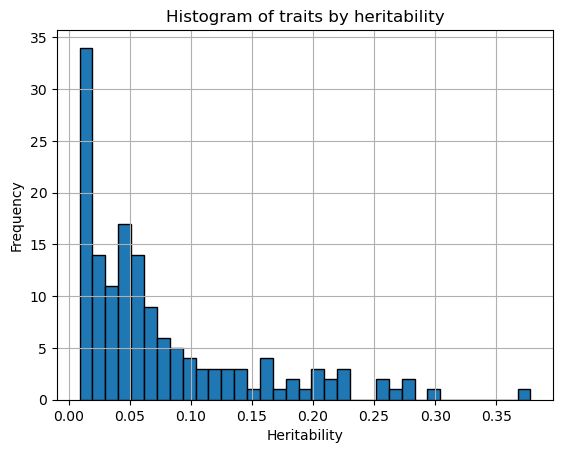

In [15]:
# Create histogram
max_ind_set['sldsc_25bin_h2_observed_EUR'].hist(bins=35, edgecolor="black")

# Show the plot
plt.xlabel("Heritability")
plt.ylabel("Frequency")
plt.title("Histogram of traits by heritability")
plt.show()


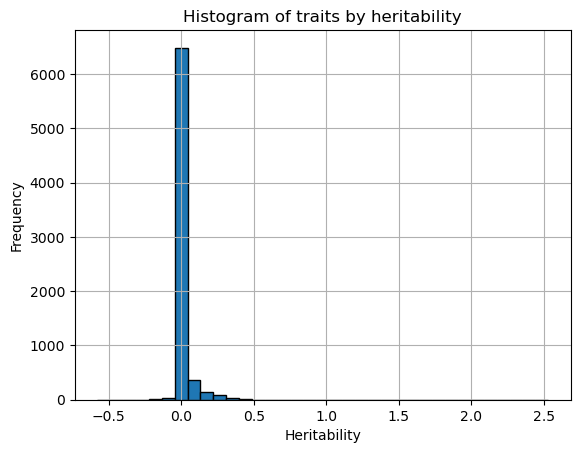

In [11]:
# Create histogram
phenotype_manifest['sldsc_25bin_h2_observed_EUR'].hist(bins=35, edgecolor="black")

# Show the plot
plt.xlabel("Heritability")
plt.ylabel("Frequency")
plt.title("Histogram of traits by heritability")
plt.show()
